In [1]:
import sys
import os
 
# Add project root to Python path
sys.path.append(os.path.abspath(".."))

In [2]:
from src.bayesian_network.label_data import label_dataset

scaled_path = "../data/processed/scaled.csv"
anomaly_path = "../results/dbscan/dbscan_anomaly_table.csv"
output_path_scaled = "../data/processed/scaled_bank_transactions_labeled.csv"

df_labeled = label_dataset(scaled_path, anomaly_path, output_path_scaled)

In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/scaled_bank_transactions_labeled.csv")
df.head()

,TransactionID,TransactionAmount,TransactionDate,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TimeSincePrev,AmountBalanceRatio,...,Channel_Online,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student,AccountID_freq,DeviceID_freq,IP Address_freq,MerchantID_freq,Location_freq,anomaly
0,TX000001,-0.971275,2023-04-11 16:29:14,1.423718,-0.552443,-0.206794,-0.000537,2024-11-04 08:08:08,-0.800762,-0.386493,...,False,False,False,False,0.394950,0.780834,-1.059021,1.141666,-0.028446,0
1,TX000002,0.269440,2023-06-27 16:44:19,1.311287,0.305314,-0.206794,2.216472,2024-11-04 08:09:35,-0.076706,-0.338188,...,False,False,False,False,0.394950,0.235683,-0.568379,0.168981,0.598373,0
2,TX000003,-0.586882,2023-07-10 18:16:08,-1.443277,-0.909842,-0.206794,-1.023534,2024-11-04 08:07:04,0.046138,-0.171040,...,True,False,False,True,-0.936152,0.235683,0.903547,0.752592,0.284963,0
3,TX000004,-0.387456,2023-05-05 16:32:11,-1.049768,-1.353017,-0.206794,0.885797,2024-11-04 08:09:06,-0.575097,-0.349611,...,True,False,False,True,0.838651,0.780834,1.394189,0.947129,-0.028446,0
4,TX000005,-0.973468,2023-10-16 17:51:24,-1.049768,1.120184,-0.206794,0.593589,2024-11-04 08:06:39,0.967391,-0.388350,...,True,False,False,True,-0.048751,-0.854621,-0.568379,0.947129,0.284963,0


In [4]:
# Drop non-numeric and unwanted columns
df = df.drop(columns=[
    "TransactionID",
    "TransactionDate",
    "Location_freq",
    "PreviousTransactionDate"
], errors="ignore")

In [5]:
df.head()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TimeSincePrev,AmountBalanceRatio,LoginRisk,TransactionCount,TransactionType_Debit,Channel_Branch,Channel_Online,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student,AccountID_freq,DeviceID_freq,IP Address_freq,MerchantID_freq,anomaly
0,-0.971275,1.423718,-0.552443,-0.206794,-0.000537,-0.800762,-0.386493,-0.225934,-1.175917,True,False,False,False,False,False,0.394950,0.780834,-1.059021,1.141666,0
1,0.269440,1.311287,0.305314,-0.206794,2.216472,-0.076706,-0.338188,-0.225934,-1.175917,True,False,False,False,False,False,0.394950,0.235683,-0.568379,0.168981,0
2,-0.586882,-1.443277,-0.909842,-0.206794,-1.023534,0.046138,-0.171040,-0.225934,-1.175917,True,False,True,False,False,True,-0.936152,0.235683,0.903547,0.752592,0
3,-0.387456,-1.049768,-1.353017,-0.206794,0.885797,-0.575097,-0.349611,-0.225934,-1.175917,True,False,True,False,False,True,0.838651,0.780834,1.394189,0.947129,0
4,-0.973468,-1.049768,1.120184,-0.206794,0.593589,0.967391,-0.388350,-0.225934,-1.175917,False,False,True,False,False,True,-0.048751,-0.854621,-0.568379,0.947129,0


In [13]:
from src.bayesian_network.preprocess2 import discretize_dataset

df_disc = discretize_dataset(df)
df_disc = df_disc.astype(int)
df_disc.head(5)

c:\Users\tewod\fraud-detection-unsupervised-learning\venv\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\tewod\fraud-detection-unsupervised-learning\venv\lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\tewod\fraud-detection-unsupervised-learning\venv\lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 7 are removed. Consider decreasing the number of bins.
  warnings.warn(


,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TimeSincePrev,AmountBalanceRatio,LoginRisk,TransactionCount,TransactionType_Debit,Channel_Branch,Channel_Online,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student,AccountID_freq,DeviceID_freq,IP Address_freq,MerchantID_freq,anomaly
0,0,3,1,0,2,1,0,0,0,1,0,0,0,0,0,2,3,0,3,0
1,2,3,2,0,3,1,1,0,0,1,0,0,0,0,0,2,2,1,2,0
2,1,0,0,0,0,2,2,0,0,1,0,1,0,0,1,0,2,3,3,0
3,1,0,0,0,3,1,1,0,0,1,0,1,0,0,1,3,3,3,3,0
4,0,0,3,0,2,3,0,0,0,0,0,1,0,0,1,2,1,1,3,0


In [14]:
from src.bayesian_network.structure_learning import learn_structure
from src.bayesian_network.cpd_learning import learn_cpds

structure_model = learn_structure(df_disc)
print(structure_model.edges())
bn_model = learn_cpds(df_disc, structure_model)

c:\Users\tewod\fraud-detection-unsupervised-learning\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 15/1000000 [00:00<17:40:26, 15.72it/s]


[('CustomerAge', 'CustomerOccupation_Student'), ('CustomerAge', 'CustomerOccupation_Retired'), ('CustomerAge', 'CustomerOccupation_Engineer'), ('AccountBalance', 'TransactionAmount'), ('AccountBalance', 'CustomerAge'), ('AccountBalance', 'CustomerOccupation_Retired'), ('AccountBalance', 'CustomerOccupation_Student'), ('AmountBalanceRatio', 'TransactionAmount'), ('AmountBalanceRatio', 'AccountBalance'), ('TransactionType_Debit', 'Channel_Online'), ('TransactionType_Debit', 'Channel_Branch'), ('Channel_Branch', 'Channel_Online'), ('CustomerOccupation_Engineer', 'CustomerOccupation_Retired'), ('CustomerOccupation_Student', 'CustomerOccupation_Engineer'), ('AccountID_freq', 'TransactionCount')]


In [15]:
for cpd in bn_model.get_cpds():
    print(cpd)

+----------------+-----+---------------------+
| AccountBalance | ... | AccountBalance(3)   |
+----------------+-----+---------------------+
| CustomerAge(0) | ... | 0.04022646007151371 |
+----------------+-----+---------------------+
| CustomerAge(1) | ... | 0.383492252681764   |
+----------------+-----+---------------------+
| CustomerAge(2) | ... | 0.32310290027810884 |
+----------------+-----+---------------------+
| CustomerAge(3) | ... | 0.25317838696861344 |
+----------------+-----+---------------------+
+-------------------------------+-----+----------------------+
| AccountBalance                | ... | AccountBalance(3)    |
+-------------------------------+-----+----------------------+
| CustomerAge                   | ... | CustomerAge(3)       |
+-------------------------------+-----+----------------------+
| CustomerOccupation_Student(0) | ... | 0.9990192232247941   |
+-------------------------------+-----+----------------------+
| CustomerOccupation_Student(1) | ... | 0.

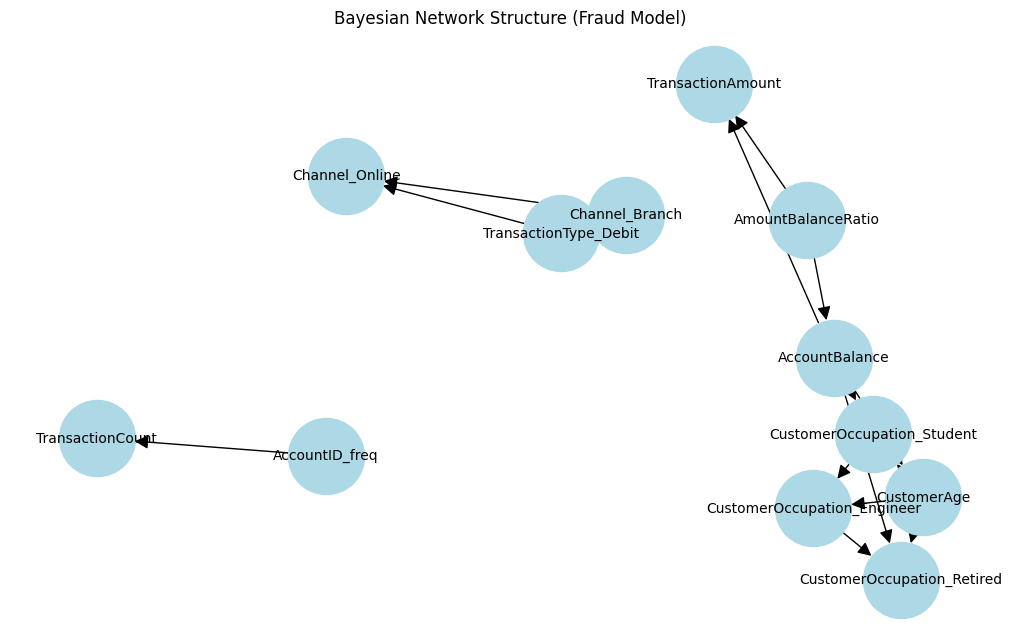

In [16]:
from src.bayesian_network.network_visualization import visualize_bn

visualize_bn(bn_model) 

---

# 📊 **Bayesian Network Analysis (Learned Structure + CPDs)**

## **1. Learned Structure**

The structure learned from the discretized dataset is:

```
[
 ('CustomerAge', 'CustomerOccupation_Student'),
 ('CustomerAge', 'CustomerOccupation_Retired'),
 ('CustomerAge', 'CustomerOccupation_Engineer'),
 ('AccountBalance', 'TransactionAmount'),
 ('AccountBalance', 'CustomerAge'),
 ('AccountBalance', 'CustomerOccupation_Retired'),
 ('AccountBalance', 'CustomerOccupation_Student'),
 ('AmountBalanceRatio', 'TransactionAmount'),
 ('AmountBalanceRatio', 'AccountBalance'),
 ('TransactionType_Debit', 'Channel_Online'),
 ('TransactionType_Debit', 'Channel_Branch'),
 ('Channel_Branch', 'Channel_Online'),
 ('CustomerOccupation_Engineer', 'CustomerOccupation_Retired'),
 ('CustomerOccupation_Student', 'CustomerOccupation_Engineer'),
 ('AccountID_freq', 'TransactionCount')
]
```

---

## 🧠 **Interpretation of the Learned Structure**

The network reveals **three major subsystems**:

---

### 🔹 **(A) Customer Demographics → Occupation → Financial State**

Key chains:

```
CustomerAge → CustomerOccupation_Student → CustomerOccupation_Engineer → CustomerOccupation_Retired
AccountBalance → CustomerAge
AccountBalance → CustomerOccupation_Student
AccountBalance → CustomerOccupation_Retired
```

**Interpretation:**

- Age influences the probability of belonging to each occupation category.
- Occupation categories form a progression chain (Student → Engineer → Retired).
- AccountBalance is a central parent variable influencing:
  - CustomerAge
  - Occupation categories  
- This suggests **financial state is a strong latent driver** of demographic segmentation.

---

### 🔹 **(B) Transaction Behavior Subsystem**

```
TransactionType_Debit → Channel_Branch → Channel_Online
TransactionType_Debit → Channel_Online
```

**Interpretation:**

- Debit transactions strongly influence which channel is used.
- Branch usage influences online usage, indicating **channel substitution patterns**.
- This subsystem captures **behavioral routing** of transactions.

---

### 🔹 **(C) Account Activity Subsystem**

```
AccountID_freq → TransactionCount
```

**Interpretation:**

- Accounts with higher frequency categories tend to generate more transactions.
- This subsystem models **account-level behavioral intensity**.

---

## **2. Conditional Probability Distributions (CPDs)**

Below are the most important CPDs extracted from the model.

---

### 🔹 **P(AccountBalance | CustomerAge)**

The distribution shows:

- Age group 1 dominates high AccountBalance(3) probability (≈ 0.38)
- Age group 0 has very low probability of high balance (≈ 0.04)

**Interpretation:**  
Middle-aged customers tend to have higher account balances.

---

### 🔹 **P(CustomerOccupation_Student | AccountBalance, CustomerAge)**

Example (for CustomerAge = 3):

```
Student(0) = 0.9990
Student(1) = 0.0010
```

**Interpretation:**  
Older customers are almost never students.

---

### 🔹 **P(CustomerOccupation_Retired | AccountBalance, CustomerAge, Engineer)**

Example:

```
Retired(0) = 0.9923
Retired(1) = 0.0077
```

**Interpretation:**  
Retirement probability is extremely low except in specific age–balance combinations.

---

### 🔹 **P(CustomerOccupation_Engineer | CustomerOccupation_Student)**

```
Engineer(0) = 0.5
Engineer(1) = 0.5
```

**Interpretation:**  
Student → Engineer transition is weakly informative (uniform).

---

### 🔹 **P(AmountBalanceRatio | AccountBalance)**

```
AccountBalance(0) → Ratio(0)=0.682, Ratio(1)=0.273, Ratio(2)=0.032, Ratio(3)=0.011
```

**Interpretation:**  
Low AccountBalance strongly predicts low AmountBalanceRatio.

---

### 🔹 **P(TransactionAmount | AccountBalance, AmountBalanceRatio)**

Example:

```
TransactionAmount(3) = 0.9679
```

**Interpretation:**  
High transaction amounts dominate when both balance and ratio are high.

---

### 🔹 **P(AmountBalanceRatio)** (prior)

```
Uniform: 0.25 each
```

**Interpretation:**  
The discretizer produced evenly distributed bins.

---

### 🔹 **P(TransactionType_Debit)**

```
Debit(0) = 0.2267
Debit(1) = 0.7733
```

**Interpretation:**  
Most transactions are debit-type.

---

### 🔹 **P(Channel_Online | TransactionType_Debit, Channel_Branch)**

Example:

```
Online(0) = 0.99899
Online(1) = 0.00101
```

**Interpretation:**  
Online channel usage is extremely rare in this dataset.

---

### 🔹 **P(Channel_Branch | TransactionType_Debit)**

```
Debit=0 → Branch(1)=0.442
Debit=1 → Branch(1)=0.318
```

**Interpretation:**  
Debit transactions reduce branch usage probability.

---

### 🔹 **P(AccountID_freq)**

```
freq(0)=0.2468
freq(1)=0.1733
freq(2)=0.3239
freq(3)=0.2559
```

**Interpretation:**  
Frequency category 2 is the most common.

---

### 🔹 **P(TransactionCount | AccountID_freq)**

```
freq=3 → Count(3)=0.5515
```

**Interpretation:**  
High-frequency accounts produce many transactions.

---
